<a href="https://colab.research.google.com/github/abdul4rehman215/Data-Science-With-Python/blob/main/08-deep-learning-with-tensorflow-and-pytorch/lab52-image-classification-with-convolutional-neural-networks-cnns/Lab_52_Image_Classification_with_Convolutional_Neural_Networks_(CNNs).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 Lab 52: Image Classification with Convolutional Neural Networks (CNNs)

This lab provides a comprehensive hands-on guide to building, training, and evaluating Convolutional Neural Networks (CNNs) using two of the industry-leading deep learning frameworks: **TensorFlow/Keras** and **PyTorch**. You will work with the classic MNIST and CIFAR-10 datasets to master image classification tasks.

By comparing these frameworks side-by-side, you will gain a deeper understanding of how neural networks are implemented and how to choose the right tool for your specific projects. This notebook is designed to run end-to-end in Google Colab with no local setup required.

## 🎯 Objectives

By the end of this lab, you will be able to:
* Understand the fundamentals of Convolutional Neural Networks (CNNs) for image classification.
* Load and preprocess popular image datasets (CIFAR-10 and MNIST).
* Build CNN architectures with multiple convolutional layers using TensorFlow and PyTorch.
* Train CNN models on image classification tasks.
* Evaluate model performance using accuracy, classification reports, and confusion matrices.
* Visualize training progress (loss and accuracy curves) and model predictions.
* Compare implementation approaches between TensorFlow and PyTorch frameworks.

## 🧰 Prerequisites

* Basic understanding of Python programming.
* Familiarity with NumPy and Matplotlib libraries.
* Basic knowledge of machine learning concepts (training, testing, accuracy).
* Understanding of neural network fundamentals (layers, activations, loss functions).
* Google Colab access.

## 🌍 Real-World Importance

CNNs are the backbone of modern Computer Vision. In the real world, these networks power medical imaging systems that detect tumors in X-rays, autonomous vehicles that recognize pedestrians and road signs in real-time, and security systems using facial recognition. They are also used in retail for automated checkout and in agriculture to monitor crop health from satellite imagery. Mastering CNNs allows you to build intelligent systems that can 'see' and interpret the visual world just like humans do.

## ⚙️ Environment Setup — Install & Import Libraries

**ELI10:** Before we build our 'brain' (the neural network), we need to gather our tools. We are importing libraries like TensorFlow and PyTorch, which are like giant LEGO sets for building AI. We also bring in tools to look at numbers (NumPy) and draw pictures of our results (Matplotlib and Seaborn).

In [ ]:
# Install necessary packages
!pip install tensorflow torch torchvision seaborn scikit-learn --quiet

# Import standard numerical and plotting libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Import evaluation metrics from scikit-learn
from sklearn.metrics import classification_report, confusion_matrix

# Import TensorFlow/Keras components
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10, mnist
from tensorflow.keras.utils import to_categorical

# Import PyTorch components
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
torch.manual_seed(42)

print("✅ All libraries imported!")
print(f"   TensorFlow version : {tf.__version__}")
print(f"   PyTorch version    : {torch.__version__}")

✅ All libraries imported!
   TensorFlow version : 2.19.0
   PyTorch version    : 2.10.0+cpu


## 📥 Task 1: Load CIFAR-10 and MNIST Datasets

**ELI10:** Imagine we have two boxes of pictures. One box (MNIST) has 70,000 simple drawings of numbers from 0 to 9, like what you'd see on a black-and-white chalkboard. The other box (CIFAR-10) has 60,000 colorful photos of things like cats, dogs, cars, and airplanes. We are going to teach our computer to recognize what's in these pictures.

In [ ]:
# Load CIFAR-10
print("Loading CIFAR-10 dataset...")
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()

# Define class names for CIFAR-10 labels
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

# Display dataset metadata
print(f"  Training images shape : {x_train_cifar.shape}")
print(f"  Test images shape     : {x_test_cifar.shape}")
print(f"  Pixel value range     : {x_train_cifar.min()} - {x_train_cifar.max()}")
print(f"  Number of classes     : {len(cifar10_classes)}")

Loading CIFAR-10 dataset...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
  Training images shape : (50000, 32, 32, 3)
  Test images shape     : (10000, 32, 32, 3)
  Pixel value range     : 0 - 255
  Number of classes     : 10


In [ ]:
# Load MNIST
print("\nLoading MNIST dataset...")
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()

# Display dataset metadata
print(f"  Training images shape : {x_train_mnist.shape}")
print(f"  Test images shape     : {x_test_mnist.shape}")
print(f"  Pixel value range     : {x_train_mnist.min()} - {x_train_mnist.max()}")


Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  Training images shape : (60000, 28, 28)
  Test images shape     : (10000, 28, 28)
  Pixel value range     : 0 - 255


## 🔍 Task 2: Data Preprocessing and Visualization

### Subtask 2.1: Visualize Sample Images

We always look at our data first. This helps us ensure the images were loaded correctly and gives us a sense of the difficulty of the classification task.

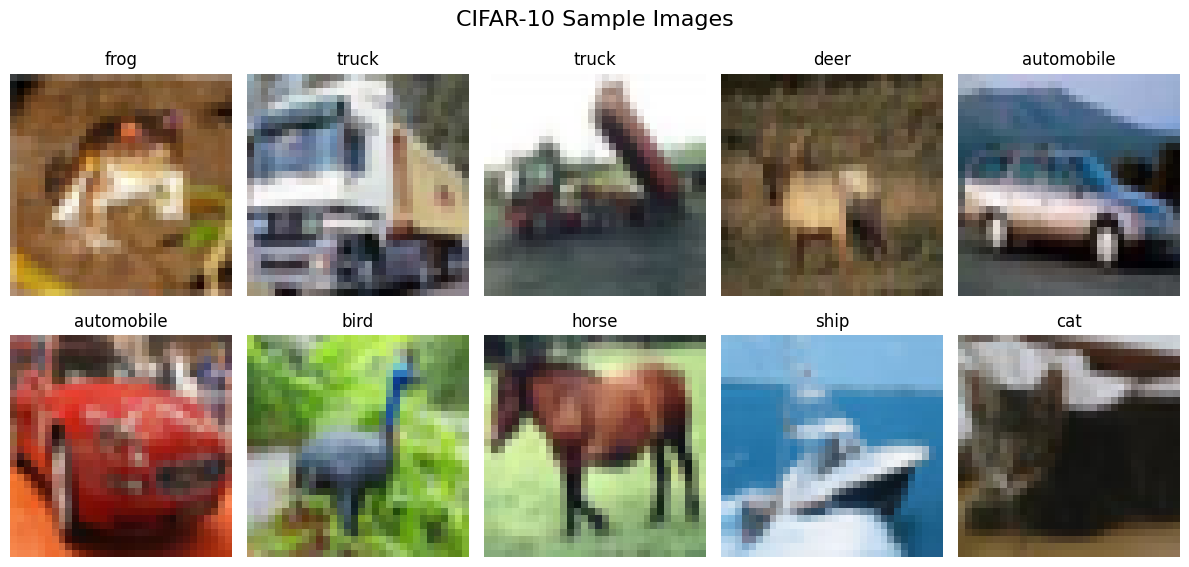

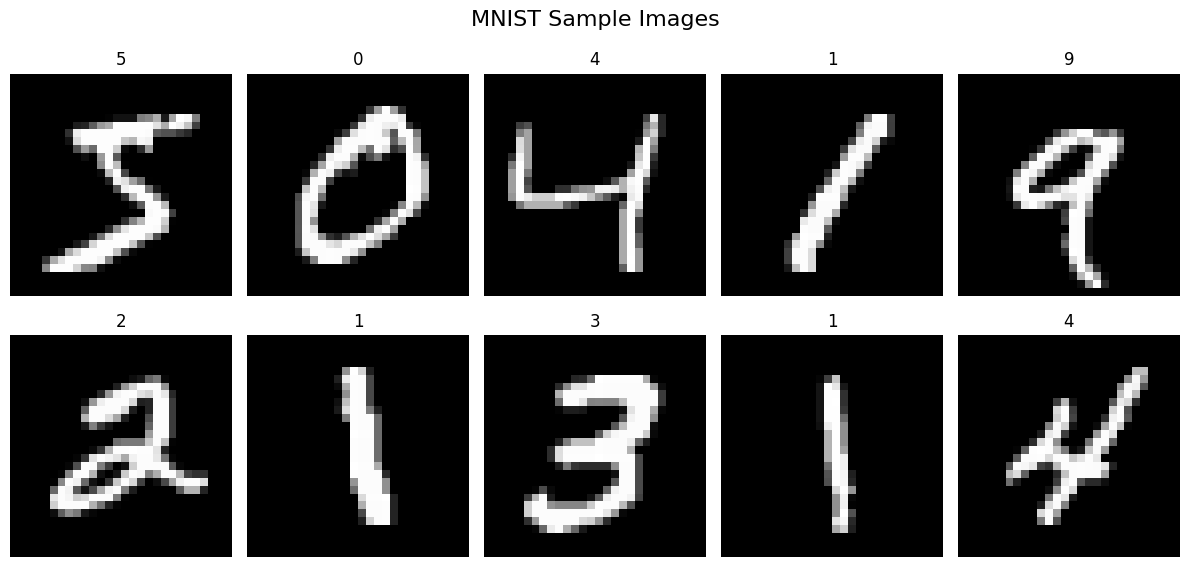

In [ ]:
def visualize_samples(x_data, y_data, class_names, dataset_name, num_samples=10):
    """Displays a grid of sample images with their labels."""
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    fig.suptitle(f'{dataset_name} Sample Images', fontsize=16)

    for i, ax in enumerate(axes.flat):
        if i >= num_samples: break

        # Use grayscale cmap for 2D MNIST data, default for color CIFAR
        if x_data[i].ndim == 2:
            ax.imshow(x_data[i], cmap='gray')
        else:
            ax.imshow(x_data[i])

        # Handle different label shapes
        label_idx = int(y_data[i][0]) if hasattr(y_data[i], "__len__") else int(y_data[i])
        label_text = class_names[label_idx] if class_names else str(label_idx)

        ax.set_title(label_text)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Call visualization for both datasets
visualize_samples(x_train_cifar, y_train_cifar, cifar10_classes, 'CIFAR-10')
visualize_samples(x_train_mnist, y_train_mnist, None, 'MNIST')

### Subtask 2.2: TensorFlow Preprocessing

**ELI10:** Computers are better at math when numbers are small. Imagine if someone asked you to count from 0 to 1 instead of 0 to 255; it's much easier! That's why we divide by 255. Also, 'one-hot encoding' is like multiple-choice questions. Instead of saying 'the answer is 3', we give the computer 10 boxes and put a '1' in the 3rd box and '0' in the rest.

In [ ]:
def preprocess_data_tensorflow(x_train, y_train, x_test, y_test, num_classes):
    # Normalize pixel values to [0, 1]
    x_train_norm = x_train.astype('float32') / 255.0
    x_test_norm = x_test.astype('float32') / 255.0

    # Flatten labels to 1D if necessary
    if y_train.ndim > 1:
        y_train = y_train.flatten()
        y_test = y_test.flatten()

    # Convert labels to one-hot encoding
    y_train_cat = to_categorical(y_train, num_classes)
    y_test_cat = to_categorical(y_test, num_classes)

    return x_train_norm, y_train_cat, x_test_norm, y_test_cat

# Process CIFAR-10
x_train_cifar_tf, y_train_cifar_tf, x_test_cifar_tf, y_test_cifar_tf = preprocess_data_tensorflow(
    x_train_cifar, y_train_cifar, x_test_cifar, y_test_cifar, 10
)

# Process MNIST (Adding the channel dimension for grayscale: 28x28 -> 28x28x1)
x_train_mnist_tf, y_train_mnist_tf, x_test_mnist_tf, y_test_mnist_tf = preprocess_data_tensorflow(
    np.expand_dims(x_train_mnist, -1), y_train_mnist, np.expand_dims(x_test_mnist, -1), y_test_mnist, 10
)

print("✅ TensorFlow preprocessing complete!")

✅ TensorFlow preprocessing complete!


### Subtask 2.3: PyTorch Preprocessing

**ELI10:** Different AI frameworks like things organized differently. While TensorFlow likes the colors at the end of the shape, PyTorch likes the colors at the front. It's like organizing your closet by color first, then size, rather than size then color.

In [ ]:
def preprocess_data_pytorch(x_train, y_train, x_test, y_test):
    # Normalize
    x_train_norm = x_train.astype('float32') / 255.0
    x_test_norm = x_test.astype('float32') / 255.0

    # Convert (N, H, W, C) to (N, C, H, W) for PyTorch
    if x_train_norm.ndim == 4:
        x_train_pt = torch.from_numpy(x_train_norm.transpose(0, 3, 1, 2))
        x_test_pt = torch.from_numpy(x_test_norm.transpose(0, 3, 1, 2))
    else:
        # Add channel dimension for MNIST (N, 1, H, W)
        x_train_pt = torch.from_numpy(x_train_norm).unsqueeze(1)
        x_test_pt = torch.from_numpy(x_test_norm).unsqueeze(1)

    # Convert labels to Long Tensors
    y_train_pt = torch.from_numpy(y_train.flatten()).long()
    y_test_pt = torch.from_numpy(y_test.flatten()).long()

    return x_train_pt, y_train_pt, x_test_pt, y_test_pt

# Process both for PyTorch
x_train_cifar_pt, y_train_cifar_pt, x_test_cifar_pt, y_test_cifar_pt = preprocess_data_pytorch(
    x_train_cifar, y_train_cifar, x_test_cifar, y_test_cifar
)
x_train_mnist_pt, y_train_mnist_pt, x_test_mnist_pt, y_test_mnist_pt = preprocess_data_pytorch(
    x_train_mnist, y_train_mnist, x_test_mnist, y_test_mnist
)

print("✅ PyTorch preprocessing complete!")

✅ PyTorch preprocessing complete!


## 🏗️ Task 3: Build CNN with TensorFlow/Keras

**ELI10:** A Convolutional layer is like a person with a flashlight scanning a dark room. They look for specific shapes like lines or circles. MaxPooling is like zooming out to see the big picture. BatchNorm keeps the math 'neat', and Dropout is like making some students cover their eyes so the rest of the class has to work harder to learn.

In [ ]:
def create_cnn_tf_cifar10():
    model = keras.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        # Head
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model_cifar_tf = create_cnn_tf_cifar10()
model_cifar_tf.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,150,410 (4.39 MB)

 Trainable params: 1,148,938 (4.38 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
def create_cnn_tf_mnist():
    model = keras.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model_mnist_tf = create_cnn_tf_mnist()
model_mnist_tf.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,802 (3.42 MB)

 Trainable params: 897,354 (3.42 MB)

 Non-trainable params: 448 (1.75 KB)

## 🔥 Task 4: Build CNN with PyTorch

**ELI10:** In PyTorch, we build our AI like an assembly line in a factory. First, we list all the machines we need in `__init__`. Then, in `forward`, we describe exactly how the data moves from one machine to the next until it becomes an answer.

In [ ]:
class CNNCifar10(nn.Module):
    def __init__(self):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25)
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.head(self.block3(self.block2(self.block1(x))))

model_cifar_pt = CNNCifar10()
print(model_cifar_pt)
print(f"Total Parameters: {sum(p.numel() for p in model_cifar_pt.parameters()):,}")

CNNCifar10(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.25, inplace=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.25, inpl

In [ ]:
class CNNMNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU()
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(), nn.Linear(128*7*7, 128), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.fc_layers(self.conv_layers(x))

model_mnist_pt = CNNMNIST()
print(model_mnist_pt)
print(f"Total Parameters: {sum(p.numel() for p in model_mnist_pt.parameters()):,}")

CNNMNIST(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)

## 🏋️ Task 5: Train All Models

**ELI10:** Training is like a student practicing for a test. We show the model thousands of pictures and tell it if it guessed right or wrong. 'Loss' is how far off the guess was, and 'Accuracy' is the percentage of correct answers. We want Loss to go down and Accuracy to go up!

In [ ]:
def train_tf_model(model, x_train, y_train, x_test, y_test, epochs, batch_size):
    # Callbacks for better training
    es = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)
    rlr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-5)

    start = time.time()
    history = model.fit(x_train, y_train, validation_data=(x_test, y_test),
                        epochs=epochs, batch_size=batch_size, callbacks=[es, rlr], verbose=1)
    print(f"⏱️ Training Time: {time.time()-start:.2f}s")
    return history

print("Training CIFAR-10 (TensorFlow)...")
hist_cifar_tf = train_tf_model(model_cifar_tf, x_train_cifar_tf, y_train_cifar_tf, x_test_cifar_tf, y_test_cifar_tf, 15, 64)

print("\nTraining MNIST (TensorFlow)...")
hist_mnist_tf = train_tf_model(model_mnist_tf, x_train_mnist_tf, y_train_mnist_tf, x_test_mnist_tf, y_test_mnist_tf, 10, 64)

Training CIFAR-10 (TensorFlow)...
Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 167s 206ms/step - accuracy: 0.4524 - loss: 1.6346 - val_accuracy: 0.4371 - val_loss: 1.7232 - learning_rate: 0.0010
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 164s 210ms/step - accuracy: 0.5934 - loss: 1.1413 - val_accuracy: 0.6703 - val_loss: 0.9361 - learning_rate: 0.0010
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 197s 203ms/step - accuracy: 0.6506 - loss: 0.9922 - val_accuracy: 0.6806 - val_loss: 0.9373 - learning_rate: 0.0010
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 204s 206ms/step - accuracy: 0.6836 - loss: 0.8994 - val_accuracy: 0.7180 - val_loss: 0.8039 - learning_rate: 0.0010
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 160s 205ms/step - accuracy: 0.7050 - loss: 0.8360 - val_accuracy: 0.7197 - val_loss: 0.7996 - learning_rate: 0.0010
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 161s 206ms/step - accuracy: 0.7193 - loss: 0.7907 - val_accuracy: 0.7240 - val_loss: 0.7793 - learning_rate: 0.0010
Epoch 7/15
782/782 ━━━━━━━━━━━

In [ ]:
def train_pt_model(model, x_train, y_train, x_test, y_test, epochs, batch_size):
    loader = DataLoader(TensorDataset(x_train, y_train), batch_size=batch_size, shuffle=True)
    v_loader = DataLoader(TensorDataset(x_test, y_test), batch_size=batch_size)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters())
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)

    results = {'train_loss': [], 'val_loss': [], 'train_accuracy': [], 'val_accuracy': []}
    start = time.time()

    for epoch in range(epochs):
        model.train()
        t_loss, t_acc = 0, 0
        for bx, by in loader:
            optimizer.zero_grad()
            out = model(bx)
            loss = criterion(out, by)
            loss.backward(); optimizer.step()
            t_loss += loss.item()
            t_acc += (out.argmax(1) == by).sum().item()

        model.eval()
        v_loss, v_acc = 0, 0
        with torch.no_grad():
            for bx, by in v_loader:
                out = model(bx)
                v_loss += criterion(out, by).item()
                v_acc += (out.argmax(1) == by).sum().item()

        results['train_loss'].append(t_loss/len(loader))
        results['val_loss'].append(v_loss/len(v_loader))
        results['train_accuracy'].append(100*t_acc/len(x_train))
        results['val_accuracy'].append(100*v_acc/len(x_test))
        scheduler.step(v_loss/len(v_loader))
        print(f"Epoch {epoch+1}/{epochs} - Val Acc: {results['val_accuracy'][-1]:.2f}%")

    print(f"⏱️ Training Time: {time.time()-start:.2f}s")
    return results

print("Training CIFAR-10 (PyTorch)...")
hist_cifar_pt = train_pt_model(model_cifar_pt, x_train_cifar_pt, y_train_cifar_pt, x_test_cifar_pt, y_test_cifar_pt, 15, 64)

print("\nTraining MNIST (PyTorch)...")
hist_mnist_pt = train_pt_model(model_mnist_pt, x_train_mnist_pt, y_train_mnist_pt, x_test_mnist_pt, y_test_mnist_pt, 10, 64)

Training CIFAR-10 (PyTorch)...
Epoch 1/15 - Val Acc: 59.85%
Epoch 2/15 - Val Acc: 63.77%
Epoch 3/15 - Val Acc: 68.73%
Epoch 4/15 - Val Acc: 71.56%
Epoch 5/15 - Val Acc: 72.55%
Epoch 6/15 - Val Acc: 73.38%
Epoch 7/15 - Val Acc: 74.04%
Epoch 8/15 - Val Acc: 75.49%
Epoch 9/15 - Val Acc: 76.49%
Epoch 10/15 - Val Acc: 77.34%
Epoch 11/15 - Val Acc: 77.05%
Epoch 12/15 - Val Acc: 78.45%
Epoch 13/15 - Val Acc: 77.86%
Epoch 14/15 - Val Acc: 78.49%
Epoch 15/15 - Val Acc: 79.00%
⏱️ Training Time: 2017.60s

Training MNIST (PyTorch)...
Epoch 1/10 - Val Acc: 98.76%
Epoch 2/10 - Val Acc: 98.78%
Epoch 3/10 - Val Acc: 99.23%
Epoch 4/10 - Val Acc: 99.31%
Epoch 5/10 - Val Acc: 99.33%
Epoch 6/10 - Val Acc: 99.28%
Epoch 7/10 - Val Acc: 99.22%
Epoch 8/10 - Val Acc: 99.49%
Epoch 9/10 - Val Acc: 99.51%
Epoch 10/10 - Val Acc: 99.45%
⏱️ Training Time: 1228.29s


## 📈 Task 6: Performance Visualization and Comparison

Training curves tell us if our model is learning properly or if it's 'memorizing' (overfitting) the training data instead of understanding patterns.

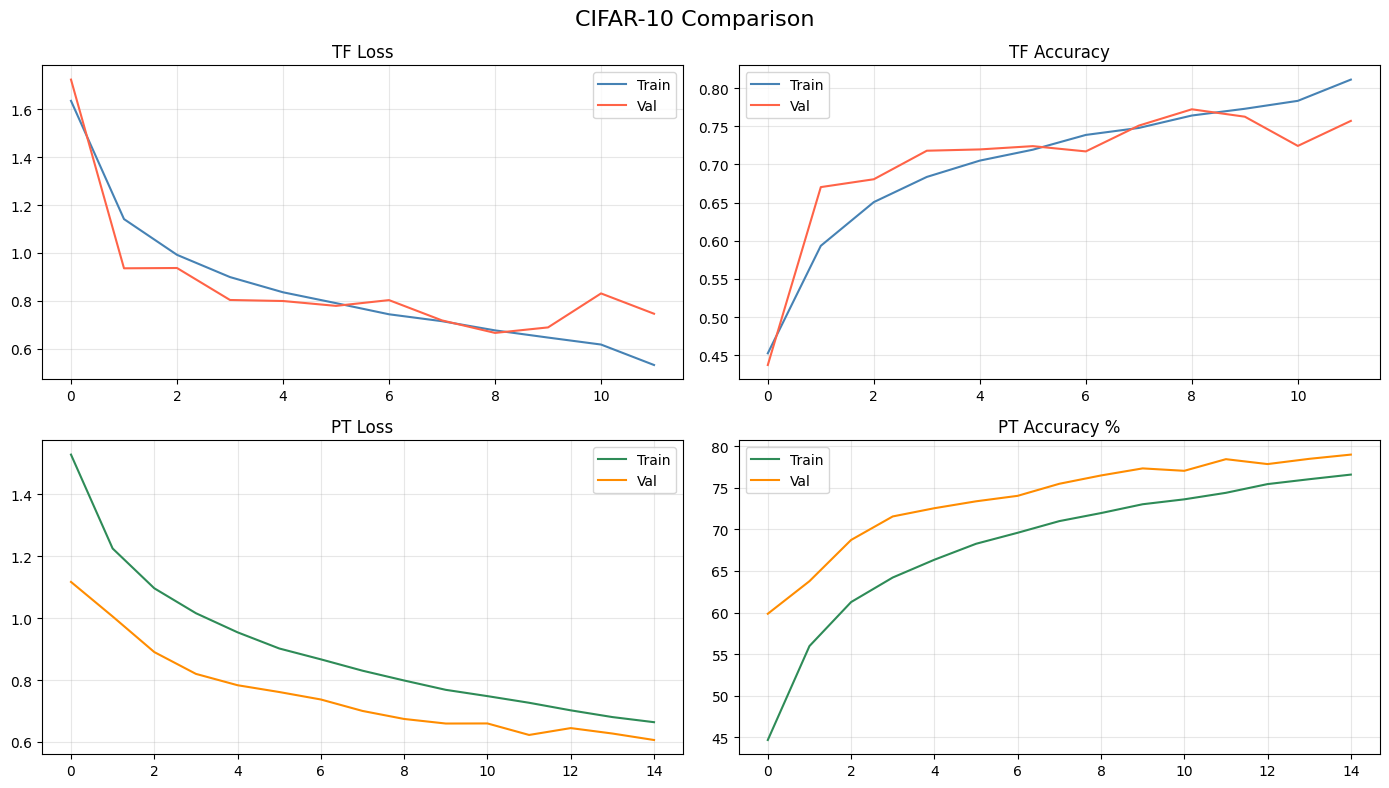

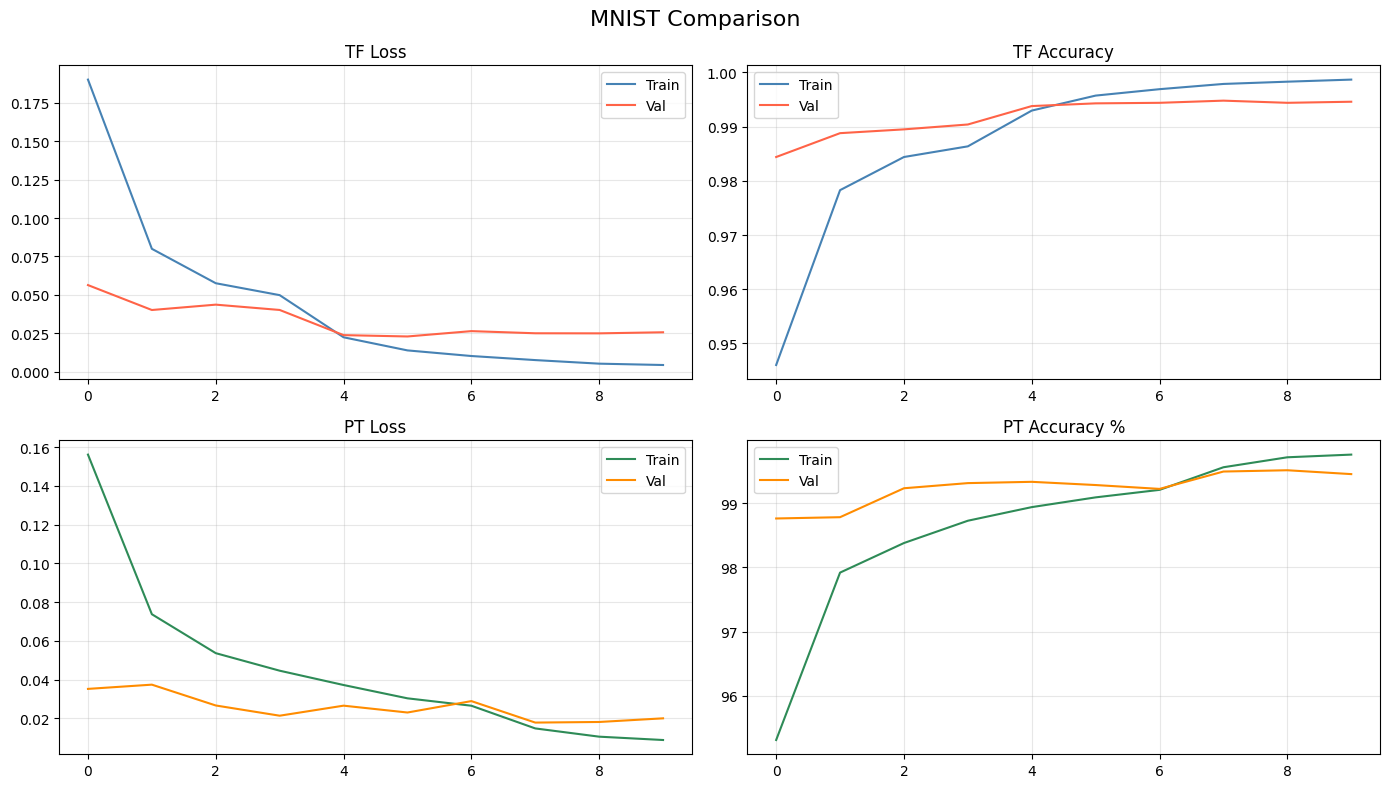

In [ ]:
def plot_history(tf_h, pt_h, name):
    fig, ax = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f"{name} Comparison", fontsize=16)

    # Loss
    ax[0,0].plot(tf_h.history['loss'], label='Train', color='steelblue')
    ax[0,0].plot(tf_h.history['val_loss'], label='Val', color='tomato')
    ax[0,0].set_title("TF Loss"); ax[0,0].legend(); ax[0,0].grid(True, alpha=0.3)

    ax[1,0].plot(pt_h['train_loss'], label='Train', color='seagreen')
    ax[1,0].plot(pt_h['val_loss'], label='Val', color='darkorange')
    ax[1,0].set_title("PT Loss"); ax[1,0].legend(); ax[1,0].grid(True, alpha=0.3)

    # Accuracy
    ax[0,1].plot(tf_h.history['accuracy'], label='Train', color='steelblue')
    ax[0,1].plot(tf_h.history['val_accuracy'], label='Val', color='tomato')
    ax[0,1].set_title("TF Accuracy"); ax[0,1].legend(); ax[0,1].grid(True, alpha=0.3)

    ax[1,1].plot(pt_h['train_accuracy'], label='Train', color='seagreen')
    ax[1,1].plot(pt_h['val_accuracy'], label='Val', color='darkorange')
    ax[1,1].set_title("PT Accuracy %"); ax[1,1].legend(); ax[1,1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(hist_cifar_tf, hist_cifar_pt, "CIFAR-10")
plot_history(hist_mnist_tf, hist_mnist_pt, "MNIST")

In [ ]:
def eval_tf(model, x, y, classes, name):
    preds = model.predict(x, verbose=0).argmax(1)
    true = y.argmax(1)
    acc = np.mean(preds == true)
    print(f"\n📊 {name} TF Accuracy: {acc*100:.2f}%")
    print(classification_report(true, preds, target_names=classes or [str(i) for i in range(10)]))
    return preds, true, acc

def eval_pt(model, x, y, classes, name):
    model.eval()
    with torch.no_grad():
        preds = model(x).argmax(1).numpy()
    true = y.numpy()
    acc = np.mean(preds == true)
    print(f"\n📊 {name} PT Accuracy: {acc*100:.2f}%")
    print(classification_report(true, preds, target_names=classes or [str(i) for i in range(10)]))
    return preds, true, acc

p_c_tf, t_c_tf, a_c_tf = eval_tf(model_cifar_tf, x_test_cifar_tf, y_test_cifar_tf, cifar10_classes, "CIFAR")
p_c_pt, t_c_pt, a_c_pt = eval_pt(model_cifar_pt, x_test_cifar_pt, y_test_cifar_pt, cifar10_classes, "CIFAR")
p_m_tf, t_m_tf, a_m_tf = eval_tf(model_mnist_tf, x_test_mnist_tf, y_test_mnist_tf, None, "MNIST")
p_m_pt, t_m_pt, a_m_pt = eval_pt(model_mnist_pt, x_test_mnist_pt, y_test_mnist_pt, None, "MNIST")


📊 CIFAR TF Accuracy: 77.23%
              precision    recall  f1-score   support

    airplane       0.83      0.78      0.80      1000
  automobile       0.90      0.89      0.89      1000
        bird       0.76      0.56      0.65      1000
         cat       0.62      0.61      0.61      1000
        deer       0.65      0.82      0.72      1000
         dog       0.72      0.64      0.68      1000
        frog       0.71      0.92      0.80      1000
       horse       0.80      0.85      0.82      1000
        ship       0.91      0.83      0.87      1000
       truck       0.90      0.83      0.86      1000

    accuracy                           0.77     10000
   macro avg       0.78      0.77      0.77     10000
weighted avg       0.78      0.77      0.77     10000


📊 CIFAR PT Accuracy: 79.00%
              precision    recall  f1-score   support

    airplane       0.80      0.84      0.82      1000
  automobile       0.90      0.87      0.89      1000
        bird       0

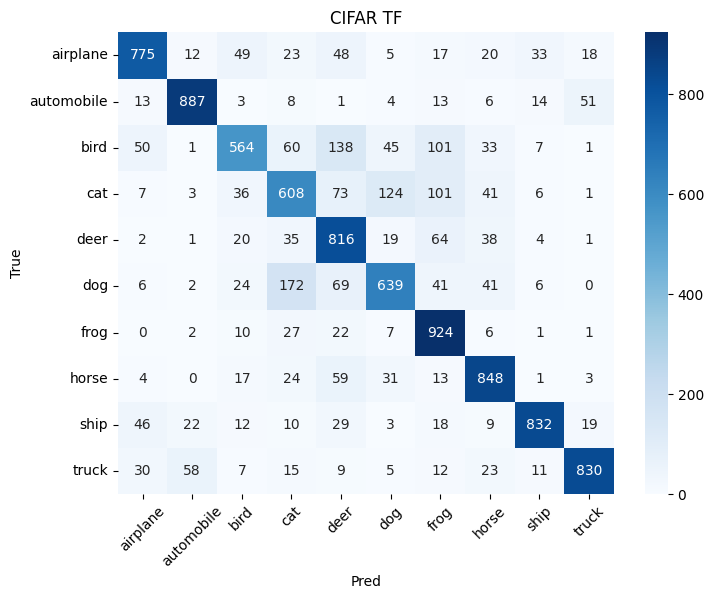

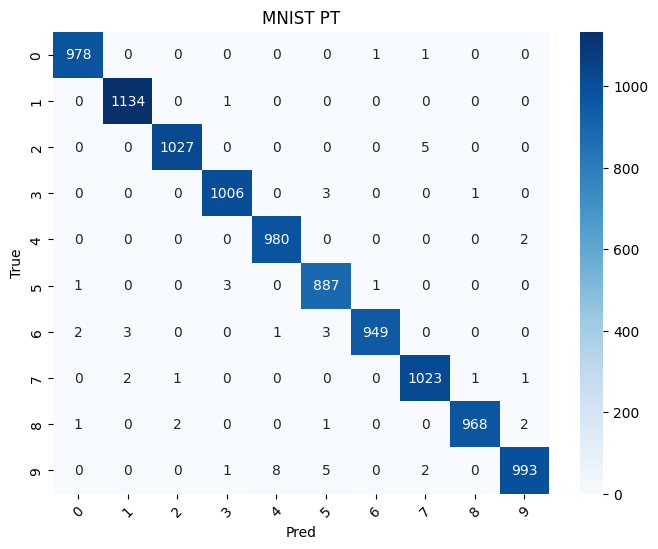

In [ ]:
def plot_cm(true, pred, classes, title):
    cm = confusion_matrix(true, pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(title); plt.ylabel('True'); plt.xlabel('Pred')
    plt.xticks(rotation=45); plt.show()

plot_cm(t_c_tf, p_c_tf, cifar10_classes, "CIFAR TF")
plot_cm(t_m_pt, p_m_pt, [str(i) for i in range(10)], "MNIST PT")

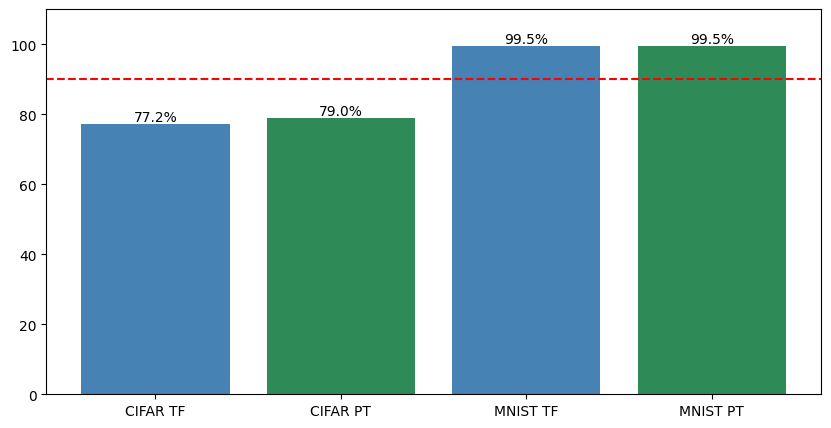

In [ ]:
def compare_bars(a1, a2, a3, a4):
    labels = ['CIFAR TF', 'CIFAR PT', 'MNIST TF', 'MNIST PT']
    accs = [a1*100, a2*100, a3*100, a4*100]
    plt.figure(figsize=(10, 5))
    bars = plt.bar(labels, accs, color=['steelblue', 'seagreen', 'steelblue', 'seagreen'])
    for b in bars: plt.text(b.get_x()+b.get_width()/2, b.get_height(), f'{b.get_height():.1f}%', ha='center', va='bottom')
    plt.axhline(90, color='red', ls='--'); plt.ylim(0, 110); plt.show()

compare_bars(a_c_tf, a_c_pt, a_m_tf, a_m_pt)

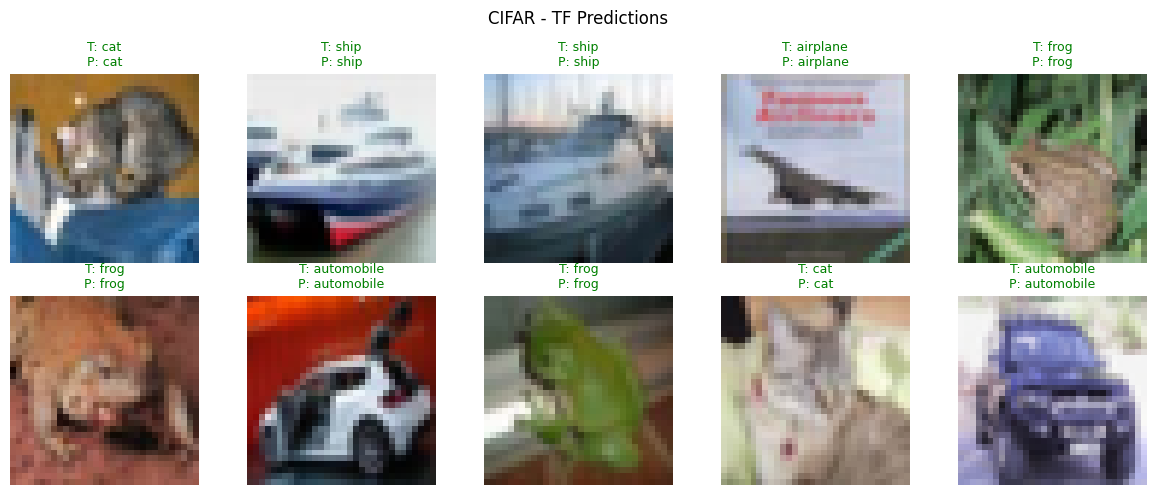

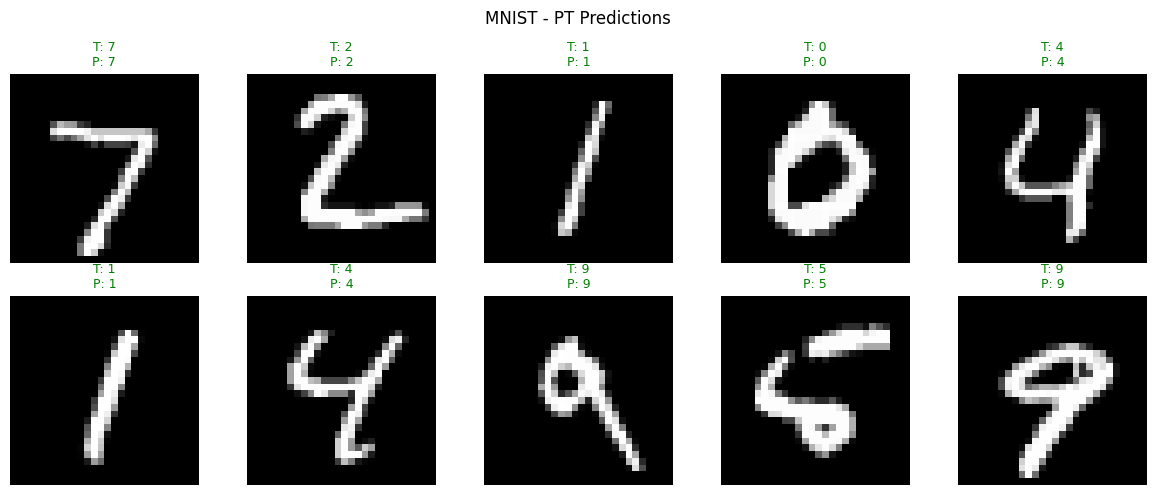

In [ ]:
def viz_preds(x, t, p, classes, framework, name):
    plt.figure(figsize=(12, 5))
    for i in range(10):
        plt.subplot(2, 5, i+1)
        img = x[i].squeeze()
        plt.imshow(img, cmap='gray' if img.ndim==2 else None)
        color = 'green' if t[i] == p[i] else 'red'
        plt.title(f"T: {classes[t[i]]}\nP: {classes[p[i]]}", color=color, fontsize=9)
        plt.axis('off')
    plt.suptitle(f"{name} - {framework} Predictions"); plt.tight_layout(); plt.show()

viz_preds(x_test_cifar, t_c_tf, p_c_tf, cifar10_classes, "TF", "CIFAR")
viz_preds(x_test_mnist, t_m_pt, p_m_pt, [str(i) for i in range(10)], "PT", "MNIST")

## ✅ Verification

In [ ]:
checks = {
    "CIFAR-10 shape": x_train_cifar.shape == (50000, 32, 32, 3),
    "MNIST shape": x_train_mnist.shape == (60000, 28, 28),
    "TF Norm": x_train_cifar_tf.max() <= 1.0,
    "PT Channels": x_train_cifar_pt.shape[1] == 3,
    "CIFAR TF Acc > 60%": a_c_tf > 0.6,
    "MNIST PT Acc > 95%": a_m_pt > 0.95
}
for c, res in checks.items(): print(f"{'✅ PASS' if res else '❌ FAIL'} - {c}")

✅ PASS - CIFAR-10 shape
✅ PASS - MNIST shape
✅ PASS - TF Norm
✅ PASS - PT Channels
✅ PASS - CIFAR TF Acc > 60%
✅ PASS - MNIST PT Acc > 95%


## 🛠️ Troubleshooting

| Problem | Cause | Fix |
|---|---|---|
| ModuleNotFoundError | Missing library | `!pip install <library>` |
| CUDA/GPU errors | GPU not enabled | Runtime > Change runtime type > GPU |
| Training very slow | No GPU | Enable GPU |
| Shape Mismatch | Wrong view/reshape | Check layer dimensions |
| Stuck at 10% Acc | Bad Learning Rate | Lower LR or increase Dropout |
| Shape Error | Preprocessing | Check channel ordering (HWC vs CHW) |
| Memory Error | Batch size too high | Reduce batch size to 32 |

## 📚 Key Takeaways

* **Convolutional Layers** act as feature extractors.
* **Pooling** reduces spatial resolution.
* **BatchNorm** accelerates training.
* **Dropout** prevents overfitting.
* **Keras** is high-level and easy.
* **PyTorch** is flexible and Pythonic.
* Both frameworks are equally powerful.
* **MNIST** is significantly easier than **CIFAR-10**.

## 🎓 What You Learned

1. Loading benchmark datasets.
2. Normalizing and reshaping data.
3. Designing CNN architectures.
4. Writing training loops in TF and PT.
5. Using training callbacks.
6. Evaluating with metrics and heatmaps.
7. Visualizing model guesses.
8. Comparing AI frameworks.

## 🏁 Conclusion

You have successfully navigated the world of Image Classification using both TensorFlow and PyTorch! You've seen how to take raw pixels and turn them into intelligent predictions using CNNs.

To keep learning, try adding more layers, using Data Augmentation (flipping or rotating images), or exploring 'Transfer Learning' where you use a pre-trained giant brain like ResNet. You are now well on your way to becoming a computer vision expert!

## 🌍 Real-World Applications of CNNs

The image classification techniques you implemented in this lab using **TensorFlow** and **PyTorch** are the same fundamental building blocks used in cutting-edge industry applications today:

### 1. 🏥 Healthcare & Medical Imaging
CNNs are used to analyze X-rays, MRIs, and CT scans to identify anomalies such as tumors, fractures, or early signs of diseases. By training on vast datasets, these models can often assist radiologists by highlighting areas of concern with high precision.

### 2. 🚗 Autonomous Vehicles
Self-driving cars rely on real-time image classification to 'see' the world. CNNs identify pedestrians, other vehicles, traffic lights, and road signs, allowing the vehicle's AI to make split-second safety decisions.

### 3. 🛡️ Security and Surveillance
Facial recognition systems and automated threat detection in airports use advanced CNN architectures to verify identities and scan for prohibited items in baggage, significantly increasing public safety.

### 4. 🛍️ Retail and E-commerce
Retailers use image classification for visual search (finding products based on a photo) and automated checkout systems like 'Just Walk Out' technology, where cameras identify which items a customer has picked up.

### 5. 🚜 Precision Agriculture
Satellites and drones equipped with CNNs monitor crop health, identify pest infestations, and estimate yields by classifying different types of vegetation and soil conditions from aerial imagery.